# Project — Chapter 80: Function Visualization Tool

> **Prerequisites:** ch051–070 (Functions and Transformations)
>
> **Concepts used:** Domain/range, function families, transformations, parameter sensitivity
>
> **Output:** An interactive multi-panel function explorer with parameter controls
>
> **Difficulty:** Intermediate | ~45 minutes

---

## 0. Overview

This is a Project chapter. Each stage builds on the previous. Read the problem statement, then execute the stages in order.

---

## 1. Setup

In [1]:
# --- Setup ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
plt.style.use('seaborn-v0_8-whitegrid')

# Function library: (name, fn_template, param_names, param_ranges, param_defaults)
FUNCTION_LIBRARY = {
    'sine':      (lambda x, A, omega, phi: A * np.sin(omega * x + phi),
                  ['A', 'omega', 'phi'], [(0.1, 3), (0.1, 5), (-np.pi, np.pi)], [1, 1, 0]),
    'logistic':  (lambda x, L, k, x0: L / (1 + np.exp(-k * (x - x0))),
                  ['L', 'k', 'x0'], [(0.5, 5), (0.1, 5), (-5, 5)], [1, 1, 0]),
    'gaussian':  (lambda x, mu, sigma, A: A * np.exp(-(x-mu)**2 / (2*sigma**2)),
                  ['mu', 'sigma', 'A'], [(-5, 5), (0.1, 3), (0.1, 3)], [0, 1, 1]),
    'power':     (lambda x, n, a: a * np.abs(x)**n * np.sign(x),
                  ['n', 'a'], [(0.1, 5), (-3, 3)], [2, 1]),
}
print("Function library loaded:", list(FUNCTION_LIBRARY.keys()))

Function library loaded: ['sine', 'logistic', 'gaussian', 'power']


---

## 2. Stage 1 — Static Multi-Function Plot

Plot all four function families with default parameters to establish a visual reference.

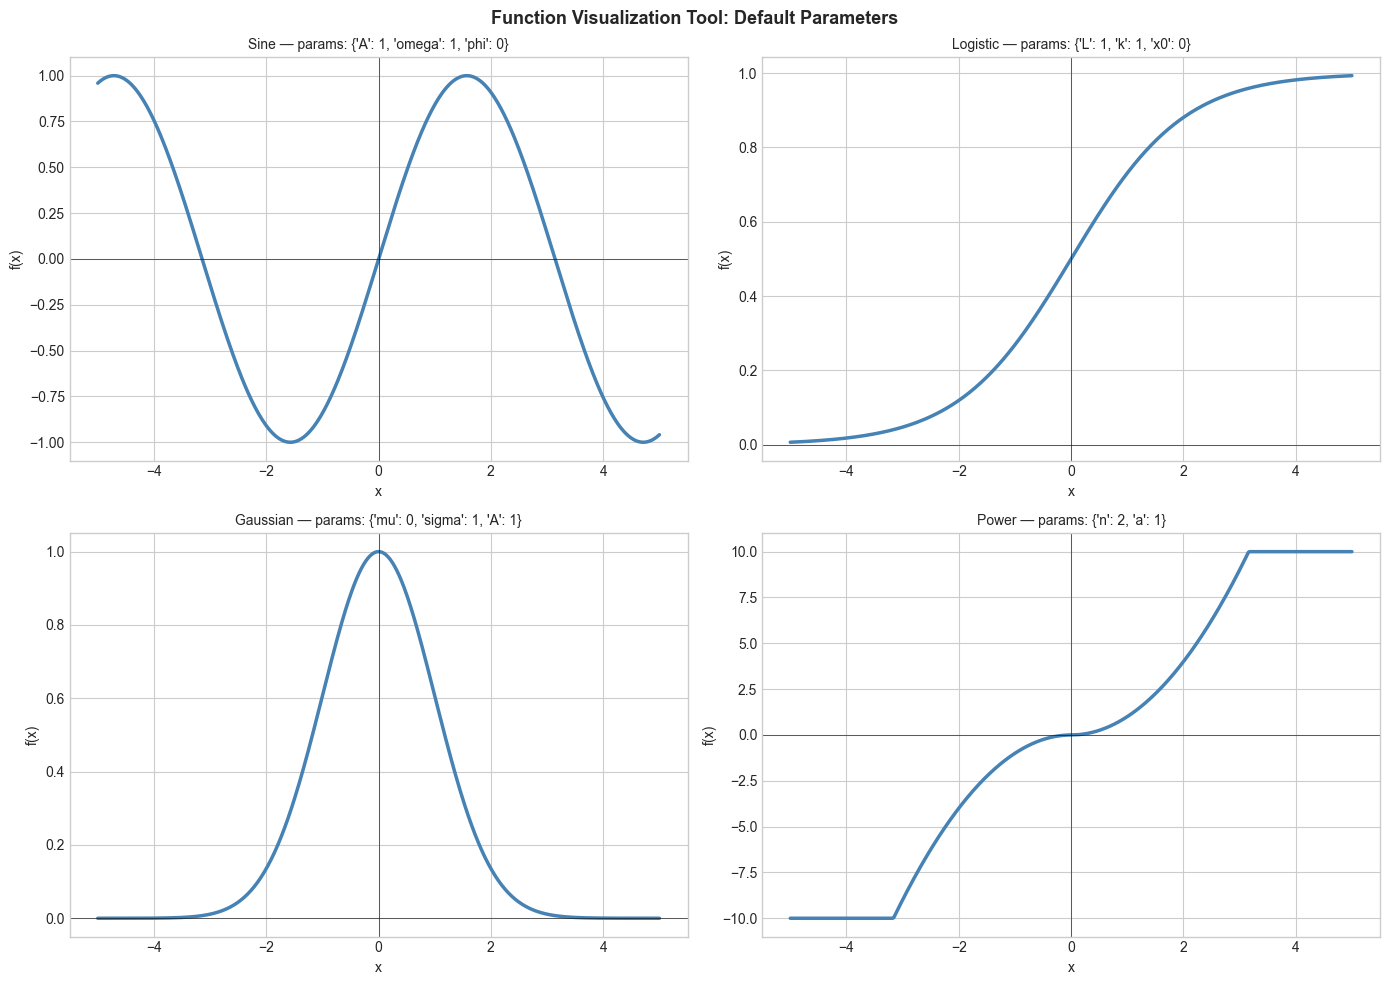

In [3]:
# Stage 1: Plot all functions with default parameters
x = np.linspace(-5, 5, 500)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, (fn, params, ranges, defaults)) in zip(axes.flat, FUNCTION_LIBRARY.items()):
    with np.errstate(invalid='ignore', over='ignore'):
        y = fn(x, *defaults)
    y_clipped = np.clip(y, -10, 10)
    ax.plot(x, y_clipped, color='steelblue', linewidth=2.5)
    ax.axhline(0, color='black', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.4)
    ax.set_title(f"{name.capitalize()} — params: {dict(zip(params, defaults))}", fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')

plt.suptitle('Function Visualization Tool: Default Parameters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 3. Stage 2 — Domain and Range Analysis

For each function, compute and display the range over the domain [-5, 5], and identify any points of discontinuity.

In [5]:
# Stage 2: Domain and range analysis
x = np.linspace(-5, 5, 2000)

print("Domain and Range Analysis:")
print("-" * 60)
for name, (fn, params, ranges, defaults) in FUNCTION_LIBRARY.items():
    with np.errstate(invalid='ignore', over='ignore'):
        y = fn(x, *defaults)
    finite_mask = np.isfinite(y)
    y_valid = y[finite_mask]
    
    if len(y_valid) > 0:
        y_min, y_max = y_valid.min(), y_valid.max()
        coverage = 100 * finite_mask.sum() / len(x)
        print(f"{name:12s}: range=[{y_min:.3f}, {y_max:.3f}], domain coverage={coverage:.1f}%")
    else:
        print(f"{name:12s}: no valid outputs")

print()
# Find zeros (sign changes)
for name, (fn, params, ranges, defaults) in FUNCTION_LIBRARY.items():
    with np.errstate(invalid='ignore'):
        y = fn(x, *defaults)
    finite = np.isfinite(y)
    if finite.any():
        sign = np.sign(y[finite])
        zc = np.sum(np.diff(sign) != 0)
        print(f"{name:12s}: ~{zc} zero crossings")

Domain and Range Analysis:
------------------------------------------------------------
sine        : range=[-1.000, 1.000], domain coverage=100.0%
logistic    : range=[0.007, 0.993], domain coverage=100.0%
gaussian    : range=[0.000, 1.000], domain coverage=100.0%
power       : range=[-25.000, 25.000], domain coverage=100.0%

sine        : ~3 zero crossings
logistic    : ~0 zero crossings
gaussian    : ~0 zero crossings
power       : ~1 zero crossings


---

## 4. Stage 3 — Parameter Sensitivity Heatmap

For each function, vary two parameters on a grid and visualize how the output at a fixed x=1 changes.

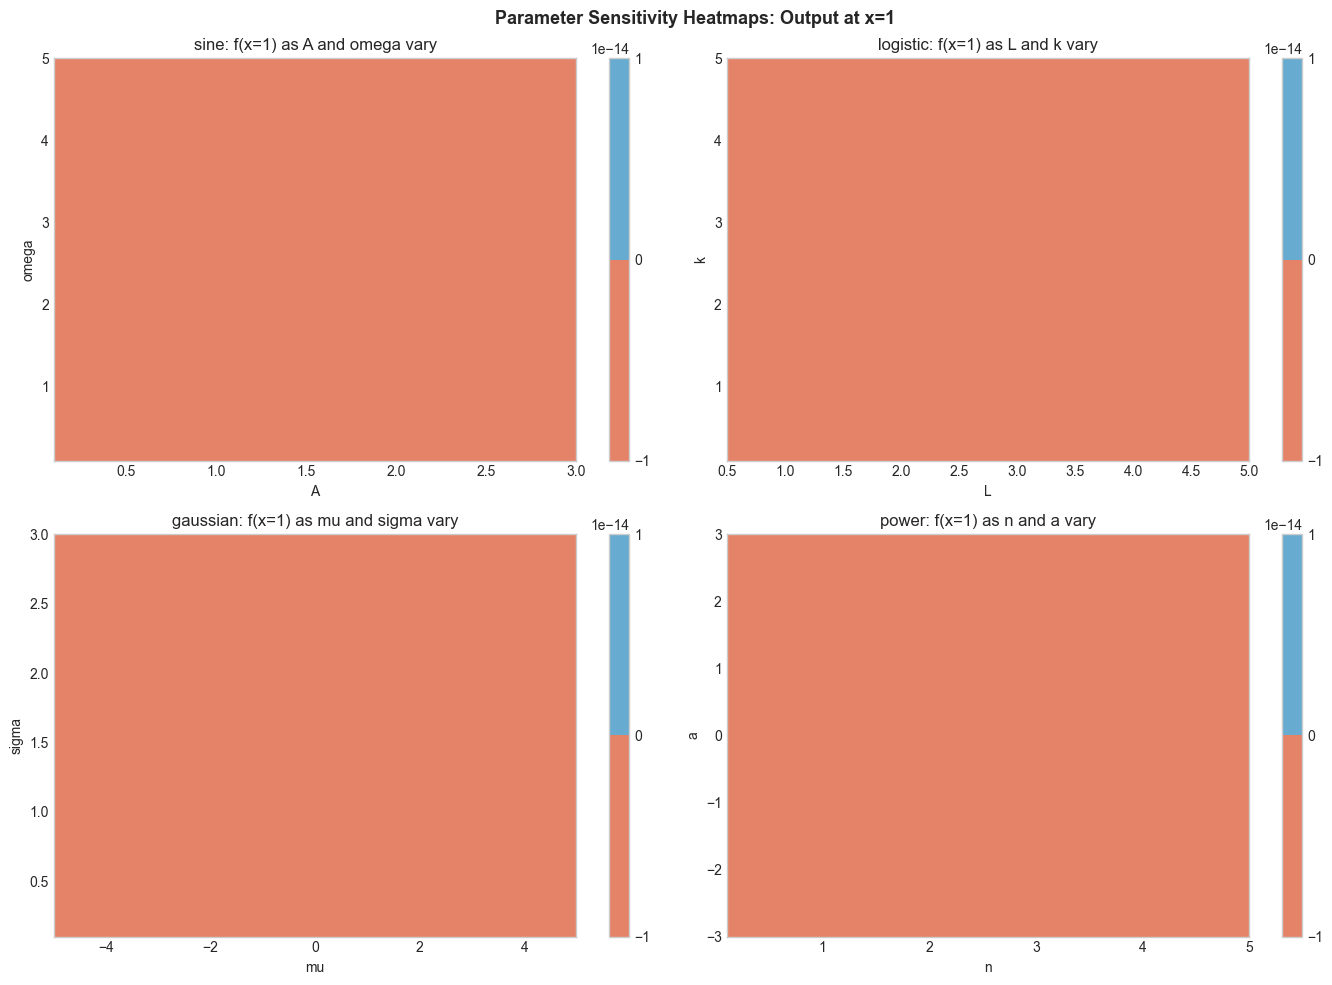

In [6]:
# Stage 3: Parameter sensitivity visualization
from itertools import combinations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

test_x = 1.0
for ax, (name, (fn, params, ranges, defaults)) in zip(axes.flat, FUNCTION_LIBRARY.items()):
    if len(params) >= 2:
        p0_range = np.linspace(*ranges[0], 30)
        p1_range = np.linspace(*ranges[1], 30)
        P0, P1 = np.meshgrid(p0_range, p1_range)
        
        Z = np.zeros_like(P0)
        for i in range(30):
            for j in range(30):
                p = defaults.copy()
                p[0] = P0[i, j]
                p[1] = P1[i, j]
                try:
                    with np.errstate(invalid='ignore', overflow='ignore'):
                        val = fn(test_x, *p)
                    Z[i, j] = val if np.isfinite(val) else 0
                except:
                    Z[i, j] = 0
        
        Z_clipped = np.clip(Z, -10, 10)
        im = ax.contourf(P0, P1, Z_clipped, levels=20, cmap='RdBu')
        plt.colorbar(im, ax=ax)
        ax.set_title(f"{name}: f(x=1) as {params[0]} and {params[1]} vary")
        ax.set_xlabel(params[0]); ax.set_ylabel(params[1])
    else:
        ax.text(0.5, 0.5, f"{name}: only 1 parameter", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name)

plt.suptitle('Parameter Sensitivity Heatmaps: Output at x=1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Stage 4 — Transformation Comparison

Apply vertical shift, horizontal shift, and scaling to one function family and display the family of curves.

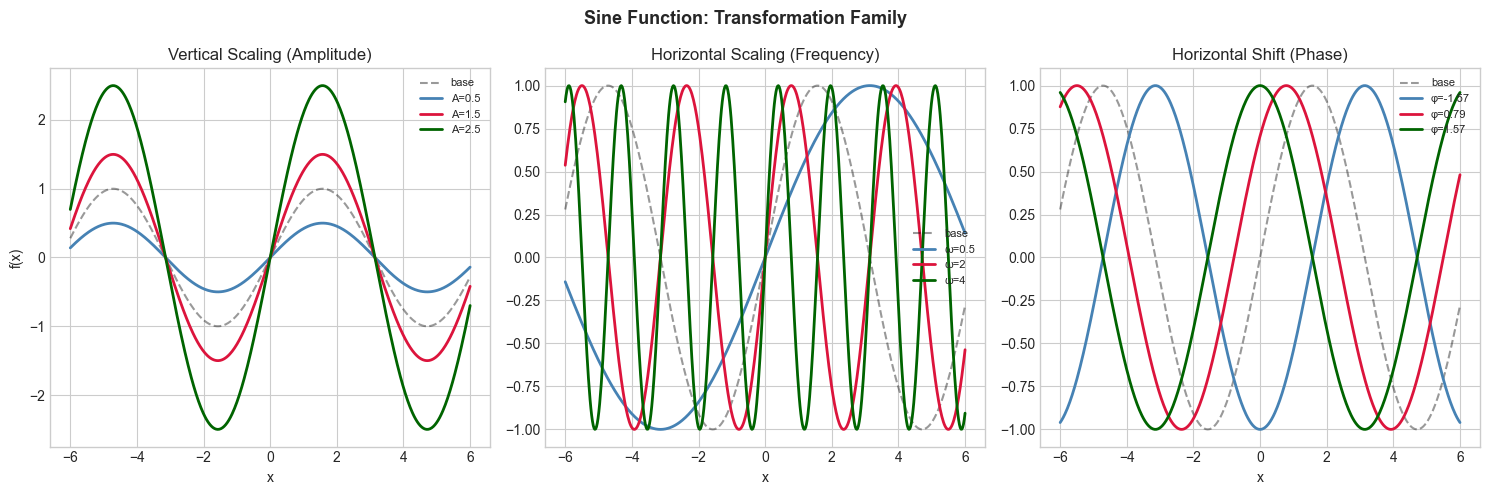

In [7]:
# Stage 4: Transformation explorer
fn, param_names, ranges, defaults = FUNCTION_LIBRARY['sine']
x = np.linspace(-6, 6, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
base = fn(x, *defaults)

# Vary amplitude
ax = axes[0]
ax.plot(x, base, 'k--', linewidth=1.5, alpha=0.4, label='base')
for A, color in zip([0.5, 1.5, 2.5], ['steelblue', 'crimson', 'darkgreen']):
    p = defaults.copy(); p[0] = A
    ax.plot(x, fn(x, *p), color=color, linewidth=2, label=f'A={A}')
ax.set_title('Vertical Scaling (Amplitude)'); ax.legend(fontsize=8)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')

# Vary frequency  
ax = axes[1]
ax.plot(x, base, 'k--', linewidth=1.5, alpha=0.4, label='base')
for omega, color in zip([0.5, 2, 4], ['steelblue', 'crimson', 'darkgreen']):
    p = defaults.copy(); p[1] = omega
    ax.plot(x, fn(x, *p), color=color, linewidth=2, label=f'ω={omega}')
ax.set_title('Horizontal Scaling (Frequency)'); ax.legend(fontsize=8)
ax.set_xlabel('x')

# Vary phase
ax = axes[2]
ax.plot(x, base, 'k--', linewidth=1.5, alpha=0.4, label='base')
for phi, color in zip([-np.pi/2, np.pi/4, np.pi/2], ['steelblue', 'crimson', 'darkgreen']):
    p = defaults.copy(); p[2] = phi
    ax.plot(x, fn(x, *p), color=color, linewidth=2, label=f'φ={phi:.2f}')
ax.set_title('Horizontal Shift (Phase)'); ax.legend(fontsize=8)
ax.set_xlabel('x')

plt.suptitle('Sine Function: Transformation Family', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 6. Results & Reflection

**What was built:**
A complete function visualization tool covering: static multi-panel plots, domain/range analysis, parameter sensitivity heatmaps, and transformation families.

**What math made it possible:**
- Function definitions and domain analysis (ch051–053)
- Function families and parameterization (ch070)
- Function transformations: shift, scale, reflect (ch066–068)
- Parameter sensitivity (ch069)

**Extension challenges:**
1. Add a 5th function family: the Weierstrass function (continuous but nowhere differentiable)
2. Add animation: smoothly morph between two parameter configurations using matplotlib's FuncAnimation
3. Extend to 2D: visualize f(x, y) = sin(x)·cos(y) as a 3D surface or contour plot